## Simple Neural Network

This notebook implements a 3-4-1 network for the XOR-like dataset. The training loop below includes a learning rate and correct weight updates.

In [2]:
import numpy as np
import pandas as pd

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [4]:
# Input and output datasets
X = np.array([[0,0,1],
              [0,1,1],
              [1,0,1],
              [1,1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

In [5]:
np.random.seed(1)
# weights: (3 -> 4) and (4 -> 1)
w0 = 2 * np.random.random((3,4)) - 1
w1 = 2 * np.random.random((4,1)) - 1

In [6]:
# Training parameters
epochs = 10000
lr = 0.1
errors = []
for i in range(epochs):
    # Forward
    a0 = X
    a1 = sigmoid(np.dot(a0, w0))
    a2 = sigmoid(np.dot(a1, w1))

    # Error
    output_error = y - a2
    errors.append({"epochs": i, "error": np.mean(np.abs(output_error))})
    if (i % 1000) == 0:
        print("Error after "+str(i)+" epochs:", np.mean(np.abs(output_error)))

    # Backprop
    layer2_delta = output_error * sigmoid_derivative(a2)
    layer1_error = layer2_delta.dot(w1.T)
    layer1_delta = layer1_error * sigmoid_derivative(a1)

    # Update weights (gradient descent)
    w1 += lr * a1.T.dot(layer2_delta)
    w0 += lr * a0.T.dot(layer1_delta)

print("Final output:")
print(a2)

Error after 0 epochs: 0.4964100319027255
Error after 1000 epochs: 0.457476916271237
Error after 2000 epochs: 0.35915769159419364
Error after 3000 epochs: 0.239581340011228
Error after 4000 epochs: 0.14319129148234894
Error after 5000 epochs: 0.09865883104560327
Error after 6000 epochs: 0.075989893853062
Error after 7000 epochs: 0.06261683996031067
Error after 8000 epochs: 0.053817892993745405
Error after 9000 epochs: 0.04757094839969516
Final output:
[[0.03499461]
 [0.95478633]
 [0.96201778]
 [0.05337798]]


<Axes: xlabel='epochs'>

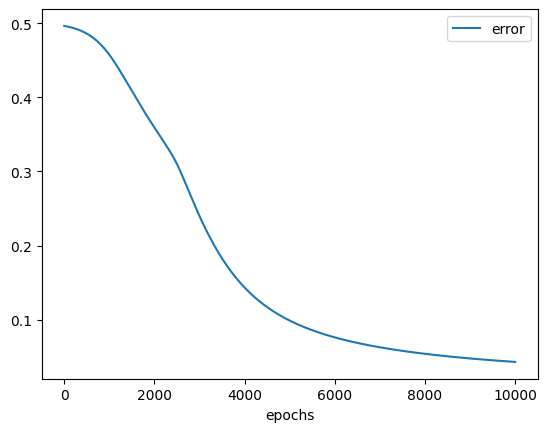

In [7]:
# Plot error curve
pd.DataFrame(errors).plot(x='epochs', y='error')